🔬 БЕНЧМАРК: ГИБРИДНЫЙ АЛГОРИТМ vs КЛАССИЧЕСКИЙ

📊 N = 1000
------------------------------------------------------------
  Гибридный алгоритм:
    Найдено простых: 86
    Отсеяно кристаллом: 556 (55.66%)
    Проверено классически: 443
    Время: 0.0033 сек

  Классический алгоритм:
    Найдено простых: 168
    Время: 0.0001 сек

  Ускорение: 0.04x

📊 N = 5000
------------------------------------------------------------
  Гибридный алгоритм:
    Найдено простых: 86
    Отсеяно кристаллом: 4556 (91.14%)
    Проверено классически: 443
    Время: 0.0106 сек

  Классический алгоритм:
    Найдено простых: 669
    Время: 0.0008 сек

  Ускорение: 0.07x

📊 N = 10000
------------------------------------------------------------
  Гибридный алгоритм:
    Найдено простых: 86
    Отсеяно кристаллом: 9556 (95.57%)
    Проверено классически: 443
    Время: 0.0194 сек

  Классический алгоритм:
    Найдено простых: 1229
    Время: 0.0018 сек

  Ускорение: 0.09x

📊 N = 20000
------------------------------

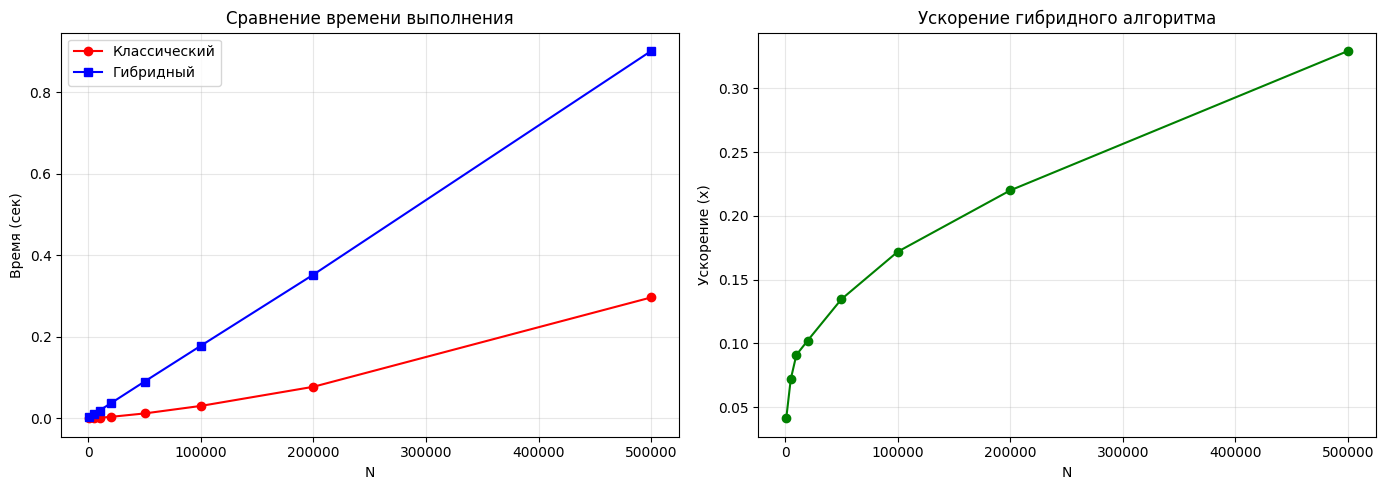


📌 ИТОГОВЫЙ ВЫВОД
  Среднее ускорение: 0.15x
  Максимальное ускорение: 0.33x


In [1]:
import math
import time
import matplotlib.pyplot as plt

# ============================================================
# 1. КЛАССИЧЕСКАЯ ПРОВЕРКА ПРОСТОТЫ
# ============================================================

def is_prime_classic(n):
    """Классическая проверка на простоту."""
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.sqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    # for i in range(3, n + 1, 2):
    #     if n % i == 0:
    #         return False
    return True

# ============================================================
# 2. ПРОВЕРКА ПРИНАДЛЕЖНОСТИ К КРИСТАЛЛУ
# ============================================================

def is_in_crystal(n, degree=2, k_max=10, exp_max=10, eps=1e-6):
    """Проверяет, попадает ли число n в кристалл."""
    x = y = n
    sum_pow = x**degree + y**degree
    z = int(round(sum_pow ** (1.0 / degree)))
    if z <= 0:
        return False
    s = sum_pow - z**degree
    F = x * y * z
    if F == 0:
        return False
    G = -s / F
    
    for k in range(2, k_max + 1):
        for exp in range(2, exp_max + 1):
            target = -1.0 / (k ** exp)
            if abs(G - target) < eps:
                return True
    return False

# ============================================================
# 3. ГИБРИДНЫЙ АЛГОРИТМ (КРИСТАЛЛ + КЛАССИКА)
# ============================================================

def find_primes_hybrid(N, degree=2):
    """
    Гибридный алгоритм:
    1. Отсеивает составные числа через кристалл.
    2. Проверяет оставшиеся числа классически.
    """
    primes = []
    crystal_filtered = 0
    classic_checked = 0
    
    for n in range(2, N + 1):
        # Шаг 1: проверяем кристалл
        if is_in_crystal(n, degree):
            crystal_filtered += 1
            continue
        
        # Шаг 2: классическая проверка
        classic_checked += 1
        if is_prime_classic(n):
            primes.append(n)
    
    return primes, crystal_filtered, classic_checked

# ============================================================
# 4. КЛАССИЧЕСКИЙ АЛГОРИТМ (ДЛЯ СРАВНЕНИЯ)
# ============================================================

def find_primes_classic(N):
    """Классический алгоритм поиска простых чисел."""
    primes = []
    for n in range(2, N + 1):
        if is_prime_classic(n):
            primes.append(n)
    return primes

# ============================================================
# 5. БЕНЧМАРК
# ============================================================

def benchmark(N_values):
    """Сравнивает гибридный и классический алгоритмы."""
    
    print("=" * 80)
    print("🔬 БЕНЧМАРК: ГИБРИДНЫЙ АЛГОРИТМ vs КЛАССИЧЕСКИЙ")
    print("=" * 80)
    print()
    
    results = []
    
    for N in N_values:
        print(f"📊 N = {N}")
        print("-" * 60)
        
        # --- Гибридный алгоритм ---
        start = time.time()
        primes_hybrid, filtered, checked = find_primes_hybrid(N)
        time_hybrid = time.time() - start
        
        # --- Классический алгоритм ---
        start = time.time()
        primes_classic = find_primes_classic(N)
        time_classic = time.time() - start
        
        # --- Статистика ---
        total_numbers = N - 1
        total_primes = len(primes_classic)
        speedup = time_classic / time_hybrid if time_hybrid > 0 else 0
        
        print(f"  Гибридный алгоритм:")
        print(f"    Найдено простых: {len(primes_hybrid)}")
        print(f"    Отсеяно кристаллом: {filtered} ({filtered / total_numbers * 100:.2f}%)")
        print(f"    Проверено классически: {checked}")
        print(f"    Время: {time_hybrid:.4f} сек")
        print()
        print(f"  Классический алгоритм:")
        print(f"    Найдено простых: {len(primes_classic)}")
        print(f"    Время: {time_classic:.4f} сек")
        print()
        print(f"  Ускорение: {speedup:.2f}x")
        print()
        
        results.append({
            'N': N,
            'hybrid_time': time_hybrid,
            'classic_time': time_classic,
            'speedup': speedup,'filtered': filtered,
            'total_numbers': total_numbers
        })
    
    # Визуализация
    print("=" * 80)
    print("📊 ВИЗУАЛИЗАЦИЯ")
    print("=" * 80)
    
    N_vals = [r['N'] for r in results]
    hybrid_times = [r['hybrid_time'] for r in results]
    classic_times = [r['classic_time'] for r in results]
    speedups = [r['speedup'] for r in results]
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(N_vals, classic_times, 'o-', label='Классический', color='red')
    plt.plot(N_vals, hybrid_times, 's-', label='Гибридный', color='blue')
    plt.xlabel('N')
    plt.ylabel('Время (сек)')
    plt.title('Сравнение времени выполнения')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(N_vals, speedups, 'o-', color='green')
    plt.xlabel('N')
    plt.ylabel('Ускорение (x)')
    plt.title('Ускорение гибридного алгоритма')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

# ============================================================
# 6. ЗАПУСК
# ============================================================

if __name__ == "__main__":
    # Тестируем для разных N
    N_values = [1000, 5000, 10000, 20000, 50000, 100000, 200000, 500000]
    # N_values = [1000, 5000]
    results = benchmark(N_values)
    
    # Итоговый вывод
    print("\n" + "=" * 80)
    print("📌 ИТОГОВЫЙ ВЫВОД")
    print("=" * 80)
    
    avg_speedup = sum(r['speedup'] for r in results) / len(results)
    max_speedup = max(r['speedup'] for r in results)
    
    print(f"  Среднее ускорение: {avg_speedup:.2f}x")
    print(f"  Максимальное ускорение: {max_speedup:.2f}x")